# Final Project — Step 2: Initial Data Assessment

**Student Name:** An Nguyen

**Course:** PHY-231

**Topic:** Climate, Water, and Disaster Patterns in Vietnam

---

## Datasets

| # | Dataset | Source | Time Range |
|---|---|---|---|
| 1 | **Rainfall & Temperature: Vietnam from 1901 to 2020** | World Bank Climate Change Knowledge Portal | 1901–2020 (30-yr period averages) |
| 2 | **Mass disasters in Vietnam from 1953 to 2024** | EM-DAT International Disaster Database | 1953–2023 |
| 3 | **Water levels of rivers in Vietnam** (10 rivers) | Vietnam Meteorological & Hydrological Administration | 2025–2026 |

> **Note on Dataset 1:** The climate data is grouped into four 30-year averages, not individual yearly records. This means I can compare eras but not specific years.

---

## Research Questions


1. **Does more rain in a given month actually lead to more disasters that month?**
   Joining the monthly rainfall averages dataset with the disaster dataset (event count by month).

2. **Do provinces with the most volatile rivers also appear most in disaster records?**
   Mapping each river to its province, then searching the disaster location field to count how often each province shows up.

3. **Every river has a statistical danger zone. How often does each one actually enter it?**
   Using mean and standard deviation from the river dataset to define a danger threshold per river, then calculating how often each river crosses it.

4. **Has Vietnam's rainfall pattern actually shifted over the last 90 years?**
   Comparing monthly rainfall in the earliest era (1901–1930) vs the most recent (1991–2020).

---
## Setup

In [2]:
# I'm working with about 12 csv files in total so I created a directory for them.
data_directory = "."

import os
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

os.chdir(data_directory)
print("Working directory:", os.getcwd())

Working directory: /home/22d1d6d9-1b78-435c-ac9d-af422602289c/Final Projects PHY-231


---
## Loading the Data

In [4]:
# Dataset 1: Rainfall & Temperature (1901-2020)

climate_df = pd.read_csv("precipitation_mean_max_min_temp_1901_2020_en.csv")
climate_df.columns = climate_df.columns.str.strip() 

print("Climate data loaded — shape:", climate_df.shape)
climate_df.head(5)

Climate data loaded — shape: (48, 7)


,Month,MinTemperature,MeanTemperature,MaxTemperature,Precipitation,Period,Level
0,Jan,15.86,19.77,23.72,33.59,1901-1930,1
1,Feb,16.79,20.69,24.63,28.86,1901-1930,2
2,Mar,16.74,22.18,27.68,42.81,1901-1930,3
3,Apr,21.32,25.38,29.48,67.88,1901-1930,4
4,May,23.07,26.96,30.90,176.59,1901-1930,5


In [6]:
# Dataset 2: Mass Disasters in Vietnam (1953-2023)
# One row per event. It has 14 columns but I only need 6 of them 

disaster_df = pd.read_csv("disaster_in_vietnam.csv")
print("Disaster shape:", disaster_df.shape)

key_cols = ["Start Year", "Start Month", "Disaster Type", "Location",
            "Total Deaths", "Total Affected"]
disaster_df[key_cols].head(5)

Disaster shape: (335, 46)


,Start Year,Start Month,Disaster Type,Location,Total Deaths,Total Affected
0,1953,9.0,Storm,Southern coast,1000.0,NaN
1,1956,11.0,Storm,NaN,56.0,NaN
2,1964,1.0,Epidemic,"Saigon, Mekong delta",598.0,10848.0
3,1964,9.0,Storm,China sea coast,7000.0,700000.0
4,1964,12.0,Flood,NaN,400.0,NaN


In [12]:
# Dataset 3: Water levels of rivers in Vietnam
# Each river is its own CSV file, so I loop through all of them,
# add a column for the river name, then stack everything into one table.

river_files = {
    "Song Thao (Yen Bai)":"songThao_YenBai.csv",
    "Song Ba (Phu Yen)":"songBa_PhuYen.csv",
    "Song Cau (Bac Ninh)":"songCau_BacNinh.csv",
    "Song Da (Hoa Binh)":"songDa_HoaBinh.csv",
    "Song Dak Bla (Kontum)":"songDakBla_Kontum.csv",
    "Song Kron Ana (Dak Lak)":"songKronAna_Daklak.csv",
    "Song Lo (Tuyen Quang)":"songLo_TuyenQuang.csv",
    "Song Ma (Thanh Hoa)":"songMa_ThanhHoa.csv",
    "Song Ta Trach (Hue)":"songTaTrach_Hue.csv",
    "Song Thu Bon (Quang Nam)": "songThuBon_QuangNam.csv",
}

parts = []

for river_name, filename in river_files.items():
    riv = pd.read_csv(filename)
    riv.columns = ["timestamp", "water_level_cm"]
    riv["river"] = river_name
    parts.append(riv)

river_df["timestamp"] = pd.to_datetime(river_df["timestamp"])
river_df["month"] = river_df["timestamp"].dt.month # need to extract month for later use when I merge them.
# month is a common denominator here

print("River - shape:", river_df.shape)
print("Number of rivers:", river_df["river"].nunique())
river_df.head(5)

River - shape: (20743, 4)
Number of rivers: 10


,timestamp,water_level_cm,river,month
0,2025-05-21 01:00:00,2517.0,Song Thao (Yen Bai),5
1,2025-05-21 04:00:00,2529.0,Song Thao (Yen Bai),5
2,2025-05-21 07:00:00,2537.0,Song Thao (Yen Bai),5
3,2025-05-21 10:00:00,2540.0,Song Thao (Yen Bai),5
4,2025-05-21 13:00:00,2545.0,Song Thao (Yen Bai),5


---
## Apply some SQL queries


In [11]:
conn = sqlite3.connect(":memory:")

climate_df.to_sql("climate", conn, if_exists="replace", index=False)
disaster_df.to_sql("disasters", conn, if_exists="replace", index=False)
river_df.to_sql("rivers", conn, if_exists="replace", index=False)

print("Loaded into SQLite:")
print("climate", len(climate_df), "rows")
print("disasters", len(disaster_df), "rows")
print("rivers", len(river_df), "rows")

Loaded into SQLite:
climate 48 rows
disasters 335 rows
rivers 20743 rows


In [13]:
# Query 1: How many flood/storm events happened each month?
# This is the disaster side of question 1.

q1 = pd.read_sql_query("""
    SELECT "Start Month" AS month,
           COUNT(*) AS event_count
    FROM disasters
    WHERE "Disaster Type" IN ('Flood', 'Storm')
    AND "Start Month" IS NOT NULL
    GROUP BY month
    ORDER BY month
""", conn)

print("Flood/Storm events by month:")
print(q1.to_string(index=False))

Flood/Storm events by month:
 month  event_count
   3.0            5
   4.0            5
   5.0           10
   6.0           13
   7.0           30
   8.0           33
   9.0           45
  10.0           45
  11.0           36
  12.0           14


In [14]:
# Query 2: How much does each river's water level swing?
# Range = max minus min. Used in Question 2.

q2 = pd.read_sql_query("""
    SELECT river,
    MAX(water_level_cm) - MIN(water_level_cm) AS level_range
    FROM rivers
    GROUP BY river
    ORDER BY level_range DESC
""", conn)

print("River water level range:")
print(q2.to_string(index=False))

River water level range:
                   river  level_range
     Song Cau (Bac Ninh)       5001.0
 Song Kron Ana (Dak Lak)       1649.0
       Song Ba (Phu Yen)       1605.0
   Song Lo (Tuyen Quang)       1531.0
Song Thu Bon (Quang Nam)       1528.0
      Song Da (Hoa Binh)       1451.0
     Song Thao (Yen Bai)       1396.0
     Song Ma (Thanh Hoa)       1103.0
   Song Dak Bla (Kontum)        732.0
     Song Ta Trach (Hue)        552.0


In [15]:
# Query 3: Pull natural disaster records that have a location listed.
# I'll search these for province names in Question 2.

q3 = pd.read_sql_query("""
    SELECT "Start Year", "Disaster Type", Location, "Total Deaths"
    FROM disasters
    WHERE "Disaster Group" = 'Natural'
      AND Location IS NOT NULL
""", conn)

print("Natural disaster records with a location:", len(q3), "rows")
print()
print(q3["Location"].head(6).to_string())

Natural disaster records with a location: 248 rows

0          Southern coast
1    Saigon, Mekong delta
2         China sea coast
3    Near Cambodia border
4                   North
5     Quang Ngai province


In [16]:
# Query 4: October and November rainfall across all four eras.
# A quick look at whether the two peak flood-season months have changed.

q4 = pd.read_sql_query("""
    SELECT Period, Month, Precipitation
    FROM climate
    WHERE Month IN ('Oct', 'Nov')
    ORDER BY Period, Month
""", conn)
print("Oct/Nov rainfall by era:")
print(q4.to_string(index=False))

conn.close()

Oct/Nov rainfall by era:
   Period Month  Precipitation
1901-1930   Nov         163.53
1901-1930   Oct         228.44
1931-1960   Nov         162.83
1931-1960   Oct         228.99
1961-1990   Nov         171.67
1961-1990   Oct         237.61
1991-2020   Nov         175.14
1991-2020   Oct         232.43


---
## Graphs

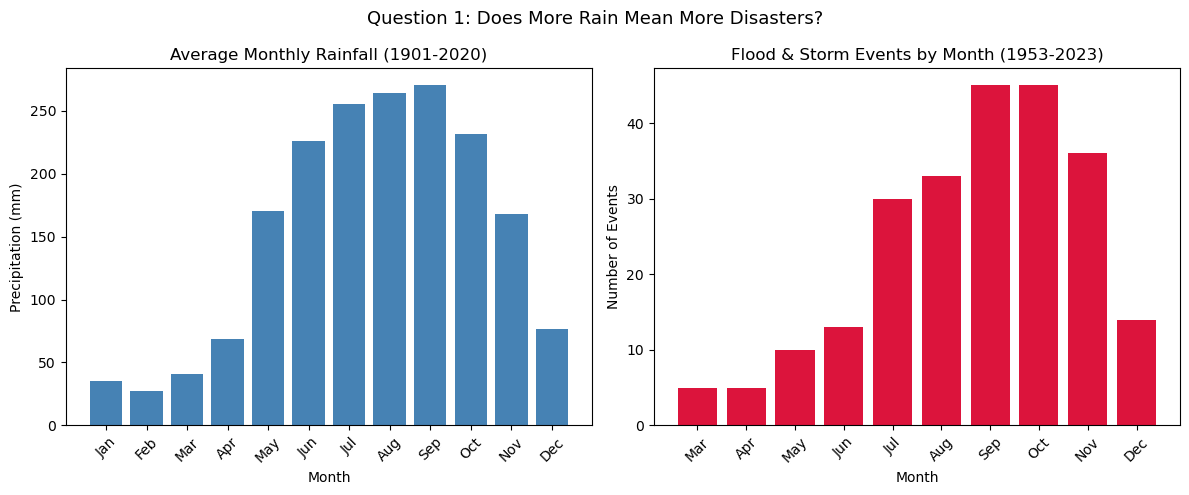

In [18]:
# Question 1: Does more rain in a given month mean more disasters?
# Left chart  => average monthly rainfall from the climate dataset
# Right chart → number of flood/storm events per month from the disaster dataset
# If they match perfectly, rain directly causes disasters in the same month.
# If they don't, some other thing is going on.

month_order  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_labels = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

climate_monthly = climate_df.groupby("Month")["Precipitation"].mean()
climate_monthly = climate_monthly.reindex(month_order)

# then add readable month names to the disaster query result
q1["month_name"] = q1["month"].map(month_labels)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(climate_monthly.index, climate_monthly.values, color="steelblue")
plt.title("Average Monthly Rainfall (1901-2020)")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(q1["month_name"], q1["event_count"], color="crimson")
plt.title("Flood & Storm Events by Month (1953-2023)")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)

plt.suptitle("Question 1: Does More Rain Mean More Disasters?", fontsize=13)
plt.tight_layout() # learn this syntax for a better visual.
plt.show()

In [27]:
# Question 2: Do provinces with volatile rivers appear more in disaster records?
# Let's think of this in 3 steps
# Step 1: map each river to the province it flows through, which luckily was provided in the file's name.
# Step 2: count how many disaster records mention that province in the Location field
# Step 3: compare river volatility vs disaster mentions, probably proceed with side-by-side bar charts

river_to_province = {
    "Song Thao (Yen Bai)":"Yen Bai",
    "Song Ba (Phu Yen)":"Phu Yen",
    "Song Cau (Bac Ninh)":"Bac Ninh",
    "Song Da (Hoa Binh)":"Hoa Binh",
    "Song Dak Bla (Kontum)":"Kon Tum",
    "Song Kron Ana (Dak Lak)":"Dak Lak",
    "Song Lo (Tuyen Quang)":"Tuyen Quang",
    "Song Ma (Thanh Hoa)":"Thanh Hoa",
    "Song Ta Trach (Hue)":"Hue",
    "Song Thu Bon (Quang Nam)":"Quang Nam",
}

natural_df = disaster_df[disaster_df["Disaster Group"] == "Natural"]

provinces  = []
ranges     = []
mentions   = []

# I need to figure out how to do a loop here to loop the province into river_to_province
# it should be something like for i in river in river_to_province...

Question 3 is still pending... I have a way, I just don't know how to code it out yet. I need to do some more research

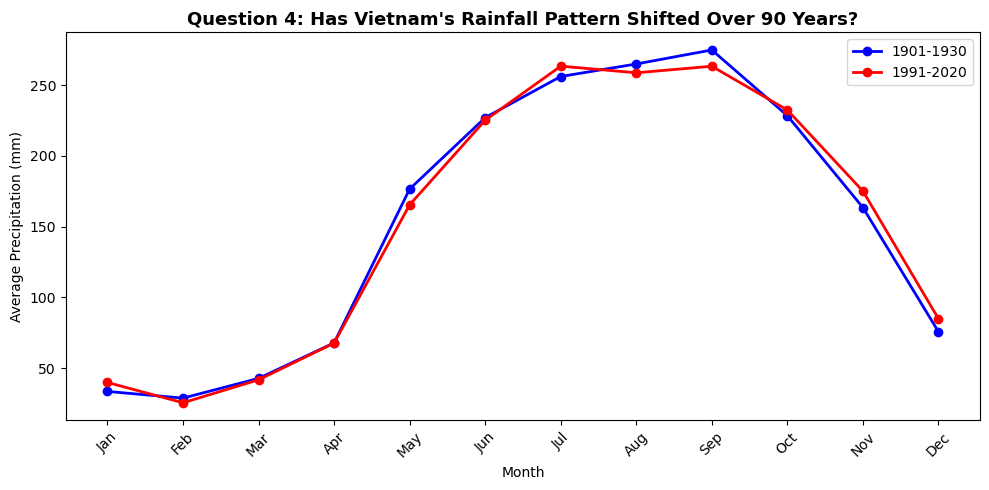

In [26]:
# Question 4: Has Vietnam's rainfall pattern actually shifted over 90 years?
# I filter down to just the two eras I want to compare:
# the earliest 30-year window (1901-1930) and the most recent (1991-2020).
# Then I reindex both by calendar month order so the chart runs Jan through Dec.

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

early  = climate_df[climate_df["Period"] == "1901-1930"].set_index("Month").reindex(month_order)
recent = climate_df[climate_df["Period"] == "1991-2020"].set_index("Month").reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(month_order, early["Precipitation"],  marker="o", label="1901-1930", color="blue", linewidth=2)
plt.plot(month_order, recent["Precipitation"], marker="o", label="1991-2020", color="red",   linewidth=2)
plt.title("Question 4: Has Vietnam's Rainfall Pattern Shifted Over 90 Years?",
          fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## So far

Starting out, I honestly expected the data to confirm what I already knew — October is dangerous, more rain means more floods, and the most dramatic rivers flow through the most disaster-prone provinces. Pretty much none of that held up cleanly when I actually looked at the numbers.

The first thing that caught me off guard was Question 1. If you just look at rainfall, August and September are the rainiest months in Vietnam — September averages over 270 mm. But when I counted actual flood and storm events, September and October tied at 45 each. June and July already have well over 200 mm of rain, yet they only show 13 and 30 disasters respectively. So the rain comes first, and then something happens — rivers fill up, soil saturates, systems build — and the disasters follow a month or so later. Rain is clearly part of the story, but it's not the whole story.

Question 2  surprised me. I expected provinces with the most volatile rivers to show up the most in disaster records. That might not be what's happening here. I checked Song Cau volatility by hand. Song Cau passes Bac Ninh province, while Song Cau has the highest volatility, Bac Ninh has only 8 disasters on file, and also, based on my experience living in Vietnam, Bac Ninh is not really notorious with natural disasters. It appeared much less on the news compared to my hometown Ha Tinh.

Question 3. Pending

Question 4. The two rainfall lines  1901–1930 and 1991–2020  follow almost the same shape. Vietnam's monsoon cycle hasn't reorganized itself in 90 years. If anything, the most recent era shows slightly higher peaks in August and September, and October is  wetter than it used to be. The pattern is intensifying a little, but it hasn't changed that much. That might sound reassuring, but paired with the disaster data showing more frequent events in recent decades, it raises a question: if the rain hasn't changed that much, why are there more disasters? Better reporting so more disasters on file? More exposure? More people living in vulnerable areas? That's something I want to dig into more.

For now, I have figured out all the ways to get to my question but not yet the codes. There would be some more advanced syntaxes I need so I'm doing the research about that. Also, there's still some more data cleaning I need to do.